Background: The client has recently taken over operations of a Retail Distribution Warehouse for a three-month transitional period. Given the recent acquisition, internal familiarity with warehouse operations and outbound process controls remains limited.

Objective:  To identify the bottleneck in inbound operations, and implement corrective measures to stabilize throughput and close the fulfillment gap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Inbound = pd.read_excel('Inbound2.xlsx')
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       357 non-null    int64 
 1   SKUlink    357 non-null    int64 
 2   SKUnumber  357 non-null    int64 
 3   Item Desc  357 non-null    object
 4   GR Qty     357 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 14.1+ KB


In [3]:
MasterData = pd.read_excel('Master Data R1.xlsx')
MasterData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SKUlink        189 non-null    int64  
 1   SKUnumber      189 non-null    int64  
 2   Category       189 non-null    object 
 3   Item Desc      189 non-null    object 
 4   UOM            189 non-null    object 
 5   ctn conv       189 non-null    int64  
 6   Hi             189 non-null    int64  
 7   Ti             189 non-null    int64  
 8   pallet conv    189 non-null    int64  
 9   Avg UnitPrice  189 non-null    float64
dtypes: float64(1), int64(6), object(3)
memory usage: 14.9+ KB


In [4]:
Inbound['Date'] = pd.to_datetime(Inbound['Date'], format='%Y%m%d')
Inbound['Weekday'] = Inbound['Date'].dt.day_name()
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       357 non-null    datetime64[ns]
 1   SKUlink    357 non-null    int64         
 2   SKUnumber  357 non-null    int64         
 3   Item Desc  357 non-null    object        
 4   GR Qty     357 non-null    int64         
 5   Weekday    357 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 16.9+ KB


In [5]:
Inbound = Inbound.merge(MasterData, on=['SKUlink', 'SKUnumber', 'Item Desc'], how='left')
Inbound.reset_index(drop=True, inplace=True)
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           357 non-null    datetime64[ns]
 1   SKUlink        357 non-null    int64         
 2   SKUnumber      357 non-null    int64         
 3   Item Desc      357 non-null    object        
 4   GR Qty         357 non-null    int64         
 5   Weekday        357 non-null    object        
 6   Category       357 non-null    object        
 7   UOM            357 non-null    object        
 8   ctn conv       357 non-null    int64         
 9   Hi             357 non-null    int64         
 10  Ti             357 non-null    int64         
 11  pallet conv    357 non-null    int64         
 12  Avg UnitPrice  357 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(7), object(4)
memory usage: 36.4+ KB


In [6]:
Inbound['Total Unit'] = np.where(
    Inbound['UOM'] == 'carton',
    Inbound['GR Qty'] * Inbound['ctn conv'],
    Inbound['GR Qty'])
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           357 non-null    datetime64[ns]
 1   SKUlink        357 non-null    int64         
 2   SKUnumber      357 non-null    int64         
 3   Item Desc      357 non-null    object        
 4   GR Qty         357 non-null    int64         
 5   Weekday        357 non-null    object        
 6   Category       357 non-null    object        
 7   UOM            357 non-null    object        
 8   ctn conv       357 non-null    int64         
 9   Hi             357 non-null    int64         
 10  Ti             357 non-null    int64         
 11  pallet conv    357 non-null    int64         
 12  Avg UnitPrice  357 non-null    float64       
 13  Total Unit     357 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(8), object(4)
memory usage: 39.2+ 

In [7]:
Inbound = pd.pivot_table(Inbound, index=['Date', 'SKUlink', 'Item Desc', 'GR Qty', 'Weekday', 'Category', 'UOM', 'ctn conv', 'Hi', 'Ti', 
                                         'pallet conv', 'Avg UnitPrice'], values='Total Unit', aggfunc='sum', fill_value=0)
Inbound.reset_index(inplace=True)
Inbound.columns.name = None
Inbound.index.name = None
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           357 non-null    datetime64[ns]
 1   SKUlink        357 non-null    int64         
 2   Item Desc      357 non-null    object        
 3   GR Qty         357 non-null    int64         
 4   Weekday        357 non-null    object        
 5   Category       357 non-null    object        
 6   UOM            357 non-null    object        
 7   ctn conv       357 non-null    int64         
 8   Hi             357 non-null    int64         
 9   Ti             357 non-null    int64         
 10  pallet conv    357 non-null    int64         
 11  Avg UnitPrice  357 non-null    float64       
 12  Total Unit     357 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(4)
memory usage: 36.4+ KB


In [8]:
Inbound['Pallets'] = np.where(
    (Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']) > 1,
    np.floor(Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv']),
    0)
Inbound['Cartons'] = np.where(
    ((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']) > 1,
    np.floor((Inbound['Total Unit'] - Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) / Inbound['ctn conv']),
    0)
Inbound['Units'] = np.where(
    (Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv'])) > 1,
    Inbound['Total Unit'] - (Inbound['Pallets'] * Inbound['ctn conv'] * Inbound['pallet conv']) - (Inbound['Cartons'] * Inbound['ctn conv']),
    0)
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           357 non-null    datetime64[ns]
 1   SKUlink        357 non-null    int64         
 2   Item Desc      357 non-null    object        
 3   GR Qty         357 non-null    int64         
 4   Weekday        357 non-null    object        
 5   Category       357 non-null    object        
 6   UOM            357 non-null    object        
 7   ctn conv       357 non-null    int64         
 8   Hi             357 non-null    int64         
 9   Ti             357 non-null    int64         
 10  pallet conv    357 non-null    int64         
 11  Avg UnitPrice  357 non-null    float64       
 12  Total Unit     357 non-null    int64         
 13  Pallets        357 non-null    float64       
 14  Cartons        357 non-null    float64       
 15  Units          357 non-

In [9]:
filtered_df = Inbound[(Inbound['Cartons'] >= 1) & (Inbound['Pallets'] >= 1)]
filtered_df

,Date,SKUlink,Item Desc,GR Qty,Weekday,Category,UOM,ctn conv,Hi,Ti,pallet conv,Avg UnitPrice,Total Unit,Pallets,Cartons,Units
70,2023-05-29,100155,Item 000155,720,Monday,GOURMET USE,unit,12,5,10,50,6.47,720,1.0,10.0,0.0
72,2023-05-29,100157,Item 000157,1200,Monday,GOURMET USE,unit,4,4,9,36,27.93,1200,8.0,12.0,0.0
128,2023-06-14,100008,Item 000008,624,Wednesday,GOURMET USE,unit,12,5,10,50,6.55,624,1.0,2.0,0.0
130,2023-06-14,100010,Item 000010,800,Wednesday,GOURMET USE,unit,4,4,9,36,28.20,800,5.0,20.0,0.0
175,2023-06-19,100167,Item 000167,768,Monday,GROCERY,unit,12,5,11,55,1.70,768,1.0,9.0,0.0
176,2023-06-19,100168,Item 000168,1824,Monday,GROCERY,unit,24,7,10,70,1.09,1824,1.0,6.0,0.0
193,2023-06-21,100157,Item 000157,2000,Wednesday,GOURMET USE,unit,4,4,9,36,27.93,2000,13.0,32.0,0.0
214,2023-06-27,100100,Item 000100,1600,Tuesday,GROCERY,unit,24,6,8,48,5.14,1600,1.0,18.0,16.0
228,2023-07-07,100104,Item 000104,800,Friday,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
333,2023-07-18,100100,Item 000100,1200,Tuesday,GROCERY,unit,24,6,8,48,5.14,1200,1.0,2.0,0.0


In [10]:
filtered_df = Inbound[(Inbound['Units'] >= 1) & (Inbound['Cartons'] >= 1) & (Inbound['Pallets'] >= 1)]
filtered_df

,Date,SKUlink,Item Desc,GR Qty,Weekday,Category,UOM,ctn conv,Hi,Ti,pallet conv,Avg UnitPrice,Total Unit,Pallets,Cartons,Units
214,2023-06-27,100100,Item 000100,1600,Tuesday,GROCERY,unit,24,6,8,48,5.14,1600,1.0,18.0,16.0
228,2023-07-07,100104,Item 000104,800,Friday,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0
354,2023-07-28,100104,Item 000104,800,Friday,GROCERY,unit,12,5,11,55,1.66,800,1.0,11.0,8.0


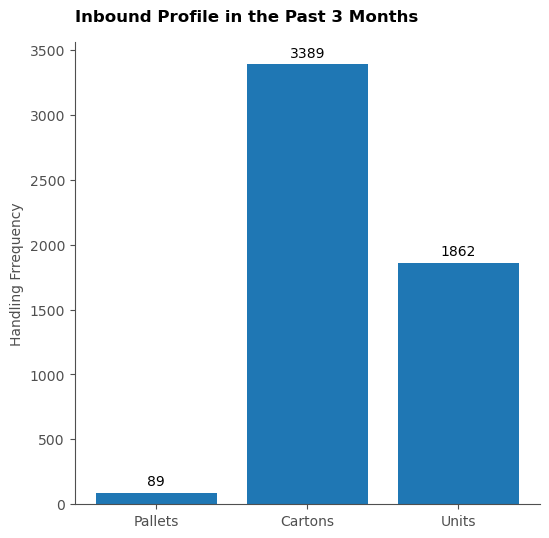

In [11]:
total_pallets = Inbound['Pallets'].sum()
total_cartons = Inbound['Cartons'].sum()
total_units = Inbound['Units'].sum()

InboundProfile = pd.DataFrame({'Inbound Profile': ['Pallets', 'Cartons', 'Units'],
                               'Total': [total_pallets, total_cartons, total_units]})

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(InboundProfile['Inbound Profile'], InboundProfile['Total'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4F4F4F')
ax.spines['bottom'].set_color('#4F4F4F')
ax.tick_params(axis='x', colors='#4F4F4F')
ax.tick_params(axis='y', colors='#4F4F4F')
ax.set_ylabel('Handling Frrequency', color='#4F4F4F')
ax.set_title('Inbound Profile in the Past 3 Months', pad=15, loc='left', fontweight='bold')
ax.bar_label(bars, padding=3)
plt.show()

- Observation: 98% of inbound activity consists of "Loose" flows (3,389 cartons and 1,862 units) compared to only 89 pallets.
- Bottleneck: The facility is physically optimized for "Full Pallet" flows. Processing thousands of loose items manually has created a disproportionate labour requirement due to the current infrastructure.
- Insight: The "Pallet-in" design is fundamentally at odds with the "Carton-in" reality of the business.
- Suggestion: Transition the receiving model from pallet-centric to a dedicated loose-carton handling flow to reduce manual touches.

In [12]:
Inbound['Pallet Mod'] = (Inbound['Total Unit'] / Inbound['ctn conv'] / Inbound['pallet conv'].round(1)) % 1
Inbound['Pallets2'] = np.where((Inbound['Pallet Mod']) >= 0.7, Inbound['Pallets']+1, Inbound['Pallets'])
Inbound.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           357 non-null    datetime64[ns]
 1   SKUlink        357 non-null    int64         
 2   Item Desc      357 non-null    object        
 3   GR Qty         357 non-null    int64         
 4   Weekday        357 non-null    object        
 5   Category       357 non-null    object        
 6   UOM            357 non-null    object        
 7   ctn conv       357 non-null    int64         
 8   Hi             357 non-null    int64         
 9   Ti             357 non-null    int64         
 10  pallet conv    357 non-null    int64         
 11  Avg UnitPrice  357 non-null    float64       
 12  Total Unit     357 non-null    int64         
 13  Pallets        357 non-null    float64       
 14  Cartons        357 non-null    float64       
 15  Units          357 non-

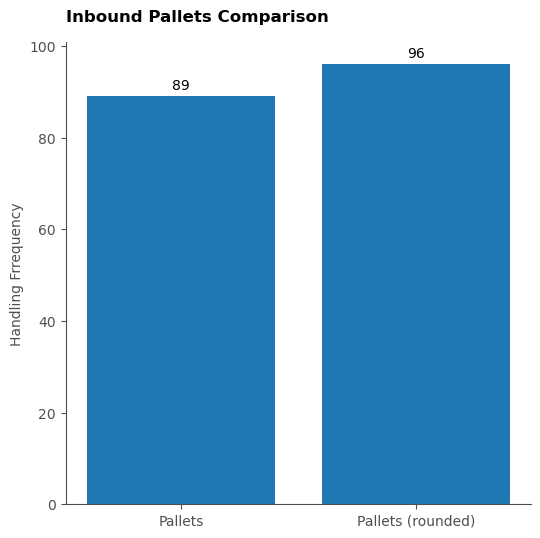

In [13]:
total_pallets = Inbound['Pallets'].sum()
total_pallets2 = Inbound['Pallets2'].sum()

InboundProfile = pd.DataFrame({'Inbound Profile': ['Pallets', 'Pallets (rounded)'],
                               'Total': [total_pallets, total_pallets2]})

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(InboundProfile['Inbound Profile'], InboundProfile['Total'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4F4F4F')
ax.spines['bottom'].set_color('#4F4F4F')
ax.tick_params(axis='x', colors='#4F4F4F')
ax.tick_params(axis='y', colors='#4F4F4F')
ax.set_ylabel('Handling Frrequency', color='#4F4F4F')
ax.set_title('Inbound Pallets Comparison', pad=15, loc='left', fontweight='bold')
ax.bar_label(bars, padding=3)
plt.show()

- Observation: Rounding up pallet quantities to the nearest half-pallet yielded a negligible increase in total pallet count (from 89 to 96). This confirms that current inbound volumes are significantly below full-pallet thresholds across the majority of the SKU profile.
- Bottleneck: High-frequency handling of small units is the primary labour driver, not pallet storage.
- Insight: The high ratio of loose cartons or units indicates a mature Just-In-Time (JIT) inventory strategy. 
- Suggestion: The client should retain their JIT model to minimize storage costs, but redesign the incoming process to prioritize high-velocity loose cargo.

In [14]:
Inbound1 = pd.melt(Inbound, id_vars=['Date', 'SKUlink', 'Item Desc', 'Weekday', 'Category'], value_vars=['Pallets', 'Cartons', 'Units'], 
                  var_name='UOM', value_name='Qty')
Inbound1 = Inbound1[Inbound1['Qty'] > 0].copy().reset_index(drop=True)
Inbound1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       396 non-null    datetime64[ns]
 1   SKUlink    396 non-null    int64         
 2   Item Desc  396 non-null    object        
 3   Weekday    396 non-null    object        
 4   Category   396 non-null    object        
 5   UOM        396 non-null    object        
 6   Qty        396 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 21.8+ KB


In [15]:
Inbound1.head()

,Date,SKUlink,Item Desc,Weekday,Category,UOM,Qty
0,2023-05-15,100028,Item 000028,Monday,GROCERY,Pallets,8.0
1,2023-05-15,100172,Item 000172,Monday,GROCERY,Pallets,2.0
2,2023-05-29,100155,Item 000155,Monday,GOURMET USE,Pallets,1.0
3,2023-05-29,100156,Item 000156,Monday,GOURMET USE,Pallets,4.0
4,2023-05-29,100157,Item 000157,Monday,GOURMET USE,Pallets,8.0


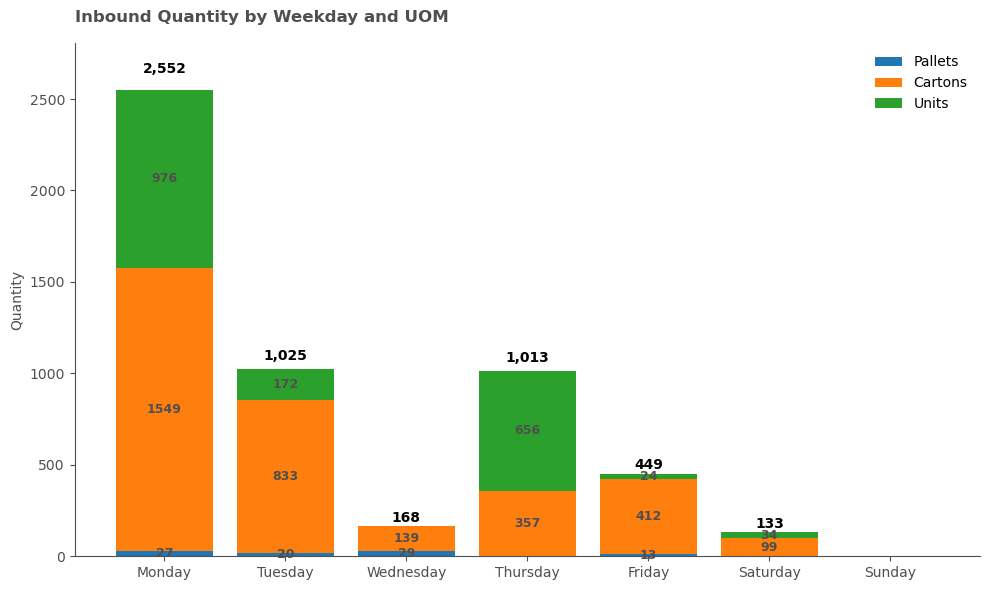

In [16]:
dark_grey = '#4F4F4F'

colors = {'Pallets': '#1f77b4',  
          'Cartons': '#ff7f0e', 
          'Units': '#2ca02c'}

stacked_data = Inbound1.pivot_table(index='Weekday',
                                    columns='UOM',
                                    values='Qty',
                                    aggfunc='sum',
                                    fill_value=0)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stacked_data = stacked_data.reindex(weekday_order).fillna(0)

x = np.arange(len(stacked_data))
fig, ax = plt.subplots(figsize=(10, 6))

row_totals = stacked_data.sum(axis=1)

bottom = np.zeros(len(stacked_data))
bars = []
for uom in ['Pallets', 'Cartons', 'Units']:
    if uom in stacked_data.columns:
        bar = ax.bar(x, stacked_data[uom], bottom=bottom, label=uom, color=colors[uom])
        for rect, qty, btm in zip(bar, stacked_data[uom], bottom):
            if qty > 0:
                ax.text(
                    rect.get_x() + rect.get_width()/2, 
                    btm + qty/2,  
                    f'{int(qty)}',
                    ha='center', va='center', color='#4F4F4F', fontweight='bold', fontsize=9)
        bottom += stacked_data[uom]
        bars.append(bar)

for i, total in enumerate(row_totals):
    if total > 0:
        ax.text(
            i,  
            total + (total * 0.03),  
            f'{int(total):,}',  
            ha='center', va='bottom', color='black', fontweight='bold', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(dark_grey)
ax.spines['bottom'].set_color(dark_grey)

ax.set_xticks(x)
ax.set_xticklabels(stacked_data.index, rotation=0)
ax.tick_params(axis='x', colors=dark_grey)
ax.tick_params(axis='y', colors=dark_grey)

ax.set_ylim(0, max(row_totals) * 1.1)

ax.set_ylabel('Quantity', color=dark_grey, fontsize=10)
ax.set_title('Inbound Quantity by Weekday and UOM', color=dark_grey, loc='left', fontweight='bold', pad=15)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- Observation: The data reveals significant inbound volatility, with Monday acting as a peak inbound day. At an average 213 touches per day, this volume is nearly 185% higher than the daily average of 75. This indicates a "front-loaded" supply chain schedule that exceeds current baseline capacity.
- Bottleneck: The Monday surge creates a throughput bottleneck at the loading dock. This high-volume arrival leads to dock congestion, which negatively impacts turnaround time and increases the risk of safety incidents and detention fees for carriers.
- Insight: There is a low capacity utilization rate on Wednesdays, Fridays, and Saturdays. This suggests labour underutilization and fixed-cost leakage, where overhead remains constant despite a drop in productive output.
- Suggestion: A more balanced flow could be achieved by collaborating with Procurement and Logistics to re-slot delivery windows, specifically shifting a portion of Monday's volume to Wednesday or Friday.

In [17]:
Inbound['Date'] = Inbound['Date'].astype(str)

with pd.ExcelWriter('[Outcome] Receiving Profile Analysis.xlsx') as writer:
    MasterData.to_excel(writer, sheet_name='MasterData', index=False)
    Inbound.to_excel(writer, sheet_name='Inbound', index=False)

Key Takeaways:
1. The facility is physically designed for "Pallet-in", but the business model is actually "Carton-in / Unit-in". This is the root cause of the fulfilment gap.
2. A 3-month transitional operation faced throughput instability. To mitigate this, a quarterly operational audit must be implemented to ensure that handling processes and labour allocation stay synchronized with the inventory requirements and SKU profiles.
3. The receiving workload could be leveled across the week by collaborating with Procurement and Logistics to pre-plan the incoming deliveries.